In [16]:
from dataclasses import dataclass, field
from datetime import datetime
from zoneinfo import ZoneInfo
from pathlib import Path

import polars as pl
import plotly.graph_objects as go
from plotly.subplots import make_subplots

PATH = r'C:\Code\Trading\2026\ml\data\minute_bars_gbpusd.parquet'
LONDON, PIP_SIZE = ZoneInfo('Europe/London'), 0.0001
OVERNIGHT_START, OVERNIGHT_END = 0, 8
SESSION_START, SESSION_END, TRADE_BEFORE = 8, 20, 10
CHOP_MULTIPLE, PIVOT_RADIUS = 1.0, 30
PLOT_DIR = Path('plots/overnight_breakout_simple')

@dataclass(frozen=True)
class Bar:
    timestamp: datetime
    bid_open: float; bid_high: float; bid_low: float; bid_close: float
    ask_open: float; ask_high: float; ask_low: float; ask_close: float
    tick_count: int
    def high(self): return (self.bid_high + self.ask_high) / 2
    def low(self): return (self.bid_low + self.ask_low) / 2

@dataclass(frozen=True)
class RangeStats:
    high: float; low: float; chop: float

@dataclass
class Position:
    direction: str; entry_timestamp: datetime; entry_price: float
    initial_stop: float; stop: float; stop_active_from: int
    range_high: float = None; range_low: float = None
    overnight_chop: float = None; chop_threshold: float = None
    stop_history: list = field(default_factory=list)

@dataclass(frozen=True)
class Trade:
    direction: str; entry_timestamp: datetime; entry_price: float
    initial_stop: float; final_stop: float
    exit_timestamp: datetime; exit_price: float; exit_reason: str; pips: float
    range_high: float; range_low: float; overnight_chop: float; chop_threshold: float
    stop_history: tuple

def london_timestamp(ts):
    return ts.replace(tzinfo=LONDON) if ts.tzinfo is None else ts.astimezone(LONDON)

def calculate_range_stats(bars):
    if not bars: return None
    high, low = max(x.high() for x in bars), min(x.low() for x in bars)
    movement = sum(x.high() - x.low() for x in bars)
    return None if movement <= 0 else RangeStats(high, low, (high - low) / movement)

def confirmed_pivot(bars, radius=PIVOT_RADIUS):
    if len(bars) < 2 * radius + 1: return None
    window, centre = bars[-(2 * radius + 1):], bars[-radius - 1]
    others = window[:radius] + window[radius + 1:]
    if all(centre.low() < x.low() for x in others): return 'low', centre.low()
    if all(centre.high() > x.high() for x in others): return 'high', centre.high()
    return None

class OvernightRangeStrategy:
    def __init__(self, chop_multiple=CHOP_MULTIPLE):
        self.chop_multiple = chop_multiple
        self.overnight_bars, self.session_bars, self.pivot_bars = [], [], []
        self.overnight_range = self.position = self.last_session_bar = None
        self.trades, self.chop_history, self.session_chop_history = [], [], []
        self.in_session, self.traded_this_session = False, False
        self.long_available = self.short_available = True
        self.bar_number = 0

    def _is_overnight(self, b): return OVERNIGHT_START <= b.timestamp.hour < OVERNIGHT_END
    def _is_session(self, b): return SESSION_START <= b.timestamp.hour < SESSION_END
    def _trading_time(self, b): return SESSION_START <= b.timestamp.hour < TRADE_BEFORE

    def _qualified(self):
        session = calculate_range_stats(self.session_bars)
        return (self.overnight_range is not None and session is not None
                and session.chop < self.overnight_range.chop * self.chop_multiple)

    def _open(self, direction, b):
        r = self.overnight_range
        if direction == 'long': entry, stop = max(r.high, b.ask_open), r.low
        else: entry, stop = min(r.low, b.bid_open), r.high
        self.position = Position(direction, b.timestamp, entry, stop, stop, self.bar_number + 1,
            r.high, r.low, r.chop, r.chop * self.chop_multiple, [(b.timestamp, stop)])
        self.traded_this_session = True

    def _close(self, b, price, reason):
        p = self.position
        side = 1 if p.direction == 'long' else -1
        self.trades.append(Trade(p.direction, p.entry_timestamp, p.entry_price, p.initial_stop,
            p.stop, b.timestamp, price, reason, side * (price - p.entry_price) / PIP_SIZE,
            p.range_high, p.range_low, p.overnight_chop, p.chop_threshold, tuple(p.stop_history)))
        self.position = None

    def _trail(self, pivot, b):
        if self.position is None or pivot is None: return
        kind, value = pivot
        if self.position.direction == 'long' and kind == 'low' and value > self.position.stop:
            self.position.stop = value; self.position.stop_history.append((b.timestamp, value))
        if self.position.direction == 'short' and kind == 'high' and value < self.position.stop:
            self.position.stop = value; self.position.stop_history.append((b.timestamp, value))

    def _manage(self, b):
        p = self.position
        if p is None or self.bar_number < p.stop_active_from: return
        if p.direction == 'long' and b.bid_low <= p.stop:
            self._close(b, min(p.stop, b.bid_open), 'stop')
        elif p.direction == 'short' and b.ask_high >= p.stop:
            self._close(b, max(p.stop, b.ask_open), 'stop')

    def _enter_if_triggered(self, b):
        if self.traded_this_session or not self._trading_time(b) or self.overnight_range is None: return
        long_touch, short_touch = b.ask_high >= self.overnight_range.high, b.bid_low <= self.overnight_range.low
        if long_touch and short_touch:
            self.long_available = self.short_available = False
        elif long_touch and self.long_available:
            if self._qualified(): self._open('long', b)
            else: self.long_available = False
        elif short_touch and self.short_available:
            if self._qualified(): self._open('short', b)
            else: self.short_available = False

    def _start_session(self):
        self.in_session, self.session_bars, self.session_chop_history, self.traded_this_session = True, [], [], False
        self.long_available = self.short_available = True

    def _finish_session(self):
        if self.position is not None:
            b = self.last_session_bar
            self._close(b, b.bid_close if self.position.direction == 'long' else b.ask_close, 'session_end')
        if self.traded_this_session:
            self.chop_history.extend(self.session_chop_history)
        self.in_session, self.last_session_bar = False, None

    def on_bar(self, b):
        self.bar_number += 1
        self.pivot_bars.append(b)
        pivot = confirmed_pivot(self.pivot_bars)
        self.pivot_bars = self.pivot_bars[-(2 * PIVOT_RADIUS + 1):]
        if self._is_overnight(b): self.overnight_bars.append(b)
        elif self.overnight_bars:
            self.overnight_range, self.overnight_bars = calculate_range_stats(self.overnight_bars), []
        if not self._is_session(b):
            if self.in_session: self._finish_session()
            return
        if not self.in_session: self._start_session()
        self.session_bars.append(b)
        session_stats = calculate_range_stats(self.session_bars)
        self.session_chop_history.append((b.timestamp, session_stats.chop if session_stats else None,
            self.overnight_range.chop * self.chop_multiple if self.overnight_range else None))
        self._trail(pivot, b)
        self._manage(b)
        self._enter_if_triggered(b)
        self.last_session_bar = b

    def finish(self):
        if self.in_session: self._finish_session()

def run_backtest(frame, include_history=False):
    strategy = OvernightRangeStrategy()
    for row in frame.iter_rows():
        values = list(row); values[0] = london_timestamp(values[0])
        strategy.on_bar(Bar(*values))
    strategy.finish()
    return (strategy.trades, strategy.chop_history) if include_history else strategy.trades


In [17]:
# def test_bar(minute, low=1.0, high=2.0):
#     return Bar(datetime(2026, 1, 5, 8, minute, tzinfo=LONDON), 1.5, high, low, 1.5, 1.5002, high + .0002, low + .0002, 1.5002, 1)
#
# low_window = [test_bar(i, 1 + abs(i - 10) / 100) for i in range(21)]
# high_window = [test_bar(i, 1, 2 - abs(i - 10) / 100) for i in range(21)]
# assert confirmed_pivot(low_window)[0] == 'low'
# assert confirmed_pivot(high_window)[0] == 'high'
# assert abs(calculate_range_stats(low_window).low - 1.0001) < 1e-12
# strategy = OvernightRangeStrategy(); strategy.position = Position('long', low_window[0].timestamp, 1.5, .9, 1.0, 0)
# strategy._trail(('low', 1.2), low_window[-1]); strategy._trail(('low', 1.1), low_window[-1])
# assert strategy.position.stop == 1.2
# # A stop is deferred on entry, then uses the adverse quote open on a gap.
# gap_test = OvernightRangeStrategy(); gap_test.overnight_range = RangeStats(1.6, .9, .4); gap_test.bar_number = 5
# gap_test._open('long', test_bar(30)); gap_test._manage(test_bar(30)); assert gap_test.position is not None
# stop_bar = Bar(datetime(2026, 1, 5, 8, 31, tzinfo=LONDON), .85, 1.0, .8, .85, .8502, 1.1, .8002, .8502, 1)
# gap_test.bar_number = 6; gap_test._manage(stop_bar)
# assert gap_test.trades[-1].exit_price == .85
# print('Synthetic validations passed.')


In [18]:
bars = pl.read_parquet(PATH)
trades, chop_history = run_backtest(bars, include_history=True)
# Keep mixed timestamp/price stop histories for plotting, not as a Polars column.
trade_log = pl.DataFrame([{
    name: value for name, value in trade.__dict__.items() if name != 'stop_history'
} for trade in trades])
trade_log


direction,entry_timestamp,entry_price,initial_stop,final_stop,exit_timestamp,exit_price,exit_reason,pips,range_high,range_low,overnight_chop,chop_threshold
str,"datetime[μs, Europe/London]",f64,f64,f64,"datetime[μs, Europe/London]",f64,str,f64,f64,f64,f64,f64
"""short""",2006-04-03 09:30:00 BST,1.725035,1.73745,1.727875,2006-04-03 11:06:00 BST,1.72792,"""stop""",-28.85,1.73745,1.725035,0.171348,0.171348
"""short""",2008-01-11 09:30:00 GMT,1.950275,1.96365,1.95575,2008-01-11 10:40:00 GMT,1.95575,"""stop""",-54.75,1.96365,1.950275,0.093777,0.093777
"""short""",2008-02-18 08:47:00 GMT,1.95085,1.963825,1.950925,2008-02-18 13:18:00 GMT,1.950925,"""stop""",-0.75,1.963825,1.95085,0.125362,0.125362
"""short""",2008-03-28 09:35:00 GMT,1.993625,2.00905,1.998275,2008-03-28 11:17:00 GMT,1.998275,"""stop""",-46.5,2.00905,1.993625,0.108322,0.108322
"""short""",2008-10-24 09:11:00 BST,1.583,1.623225,1.5606,2008-10-24 12:52:00 BST,1.5606,"""stop""",224.0,1.623225,1.583,0.112946,0.112946
…,…,…,…,…,…,…,…,…,…,…,…,…
"""long""",2025-04-16 09:59:00 BST,1.329015,1.32246,1.326065,2025-04-16 12:00:00 BST,1.326065,"""stop""",-29.5,1.329015,1.32246,0.11941,0.11941
"""short""",2025-05-07 09:46:00 BST,1.33411,1.33604,1.33573,2025-05-07 12:11:00 BST,1.33573,"""stop""",-16.2,1.33604,1.33411,0.210584,0.210584
"""long""",2025-06-09 09:29:00 BST,1.35723,1.352815,1.352815,2025-06-09 14:22:00 BST,1.352815,"""stop""",-44.15,1.35723,1.352815,0.088318,0.088318


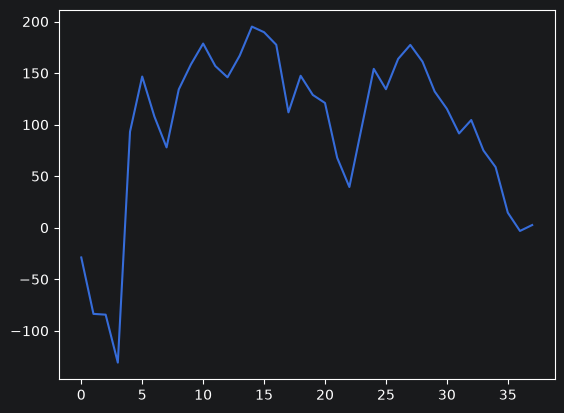

In [19]:
import matplotlib.pyplot  as plt
plt.plot(trade_log['pips'].cum_sum())

In [10]:
def midpoint_open(bar): return (bar.bid_open + bar.ask_open) / 2
def midpoint_close(bar): return (bar.bid_close + bar.ask_close) / 2

def save_trade_charts(frame, completed_trades, chop_series, output_dir=PLOT_DIR):
    """Save one interactive 00:00-20:00 London candlestick chart per trade day."""
    output_dir.mkdir(parents=True, exist_ok=True)
    trades_by_date = {trade.entry_timestamp.date(): trade for trade in completed_trades}
    bars_by_date = {day: [] for day in trades_by_date}
    chop_by_date = {day: [] for day in trades_by_date}
    for point in chop_series:
        if point[0].date() in chop_by_date and point[1] is not None:
            chop_by_date[point[0].date()].append(point)
    for row in frame.iter_rows():
        values = list(row); values[0] = london_timestamp(values[0])
        bar = Bar(*values)
        if bar.timestamp.date() in bars_by_date and 0 <= bar.timestamp.hour < SESSION_END:
            bars_by_date[bar.timestamp.date()].append(bar)

    saved_paths = []
    for day, trade in trades_by_date.items():
        day_bars = bars_by_date[day]
        if not day_bars:
            continue
        fig = make_subplots(
            rows=2, cols=1, shared_xaxes=True, vertical_spacing=.05,
            row_heights=[.75, .25], subplot_titles=('Midpoint candlesticks and trade execution', 'Session chop')
        )
        times = [bar.timestamp for bar in day_bars]
        fig.add_trace(go.Candlestick(
            x=times, open=[midpoint_open(bar) for bar in day_bars],
            high=[bar.high() for bar in day_bars], low=[bar.low() for bar in day_bars],
            close=[midpoint_close(bar) for bar in day_bars], name='Midpoint OHLC'
        ), row=1, col=1)
        fig.add_hline(y=trade.range_high, line_dash='dash', line_color='royalblue',
            annotation_text='Overnight high', row=1, col=1)
        fig.add_hline(y=trade.range_low, line_dash='dash', line_color='royalblue',
            annotation_text='Overnight low', row=1, col=1)
        stop_history = list(trade.stop_history)
        if stop_history[-1][0] < trade.exit_timestamp:
            stop_history.append((trade.exit_timestamp, trade.final_stop))
        fig.add_trace(go.Scatter(
            x=[point[0] for point in stop_history], y=[point[1] for point in stop_history],
            mode='lines', line_shape='hv', line=dict(color='firebrick', width=2), name='Trailing stop'
        ), row=1, col=1)
        entry_symbol = 'triangle-up' if trade.direction == 'long' else 'triangle-down'
        fig.add_trace(go.Scatter(
            x=[trade.entry_timestamp], y=[trade.entry_price], mode='markers', name='Entry',
            marker=dict(symbol=entry_symbol, size=13, color='green'),
            hovertemplate='Entry<br>%{x}<br>%{y:.5f}<extra></extra>'
        ), row=1, col=1)
        fig.add_trace(go.Scatter(
            x=[trade.exit_timestamp], y=[trade.exit_price], mode='markers', name=f'Exit: {trade.exit_reason}',
            marker=dict(symbol='x', size=12, color='black'),
            hovertemplate='Exit<br>%{x}<br>%{y:.5f}<extra></extra>'
        ), row=1, col=1)
        day_chop = chop_by_date[day]
        fig.add_trace(go.Scatter(
            x=[point[0] for point in day_chop], y=[point[1] for point in day_chop],
            mode='lines', line=dict(color='purple'), name='Session chop'
        ), row=2, col=1)
        fig.add_trace(go.Scatter(
            x=[point[0] for point in day_chop], y=[point[2] for point in day_chop],
            mode='lines', line=dict(color='orange', dash='dash'), name='Chop threshold'
        ), row=2, col=1)
        fig.update_layout(
            title=f'{day} {trade.direction.title()} | {trade.pips:.1f} pips | {trade.exit_reason}',
            template='plotly_white', height=850, hovermode='x unified',
            legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0)
        )
        fig.update_yaxes(title_text='Price', row=1, col=1)
        fig.update_yaxes(title_text='Ratio', row=2, col=1)
        fig.update_xaxes(title_text='London time', rangeslider_visible=False, row=2, col=1)
        chart_path = output_dir / f'{day}.html'
        fig.write_html(chart_path, include_plotlyjs='cdn', full_html=True)
        saved_paths.append(chart_path)
    return saved_paths

saved_charts = save_trade_charts(bars, trades, chop_history)
saved_charts


[WindowsPath('plots/overnight_breakout_simple/2006-04-03.html'),
 WindowsPath('plots/overnight_breakout_simple/2008-01-11.html'),
 WindowsPath('plots/overnight_breakout_simple/2008-02-18.html'),
 WindowsPath('plots/overnight_breakout_simple/2008-03-28.html'),
 WindowsPath('plots/overnight_breakout_simple/2008-10-24.html'),
 WindowsPath('plots/overnight_breakout_simple/2009-01-13.html'),
 WindowsPath('plots/overnight_breakout_simple/2009-11-03.html'),
 WindowsPath('plots/overnight_breakout_simple/2010-07-12.html'),
 WindowsPath('plots/overnight_breakout_simple/2010-09-06.html'),
 WindowsPath('plots/overnight_breakout_simple/2012-08-23.html'),
 WindowsPath('plots/overnight_breakout_simple/2013-01-11.html'),
 WindowsPath('plots/overnight_breakout_simple/2013-01-31.html'),
 WindowsPath('plots/overnight_breakout_simple/2013-04-23.html'),
 WindowsPath('plots/overnight_breakout_simple/2013-07-19.html'),
 WindowsPath('plots/overnight_breakout_simple/2013-08-21.html'),
 WindowsPath('plots/overn